# Práctica - Análisis de Redes Sociales - MDSF
**Author**: Said Daniel Huarita Mollo

Este notebook analiza un grafo de contactos cara a cara entre individuos, simulando interacciones en un período de tiempo y aplicando análisis de centralidad, detección de comunidades y simulación de propagación.

El objetivo es analizar un grafo, que se provee como fichero en el mismo paquete que este enunciado. En este fichero, encontramos solamente dos columnas, correspondiente a una interacción entre dos nodos de la red. Esta red está formada por distintos individuos que tienen contactos cara a cara durante un período de tiempo.

A continuación, dividimos la práctica en apartados, con una breve descripción de que debe contener cada chunk de código donde el alumno desarrollará su respuesta así como las explicaciones que considere oportunas. Por favor, razona todas tus soluciones y escribe las explicaciones en azul.

Junto al título de cada apartado se encuentra la puntuación del mismo (pueden obtenerse hasta 10,5 puntos, aunque solamente se evaluará del 0 al 10).



## Carga de paquetes necesarios

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Análisis de grafos
import networkx as nx

## 1. Carga de datos y comprobaciones iniciales (0.5 puntos)

En este apartado, se pide:

* Cargar el fichero adjunto en la práctica.
* Convertirlo en un objeto grafo de networkx. Se cargará como un grafo NO dirigido.
* Comprobar que, efectivamente, tiene el número de nodos y enlaces correcto.
* Simplificar: eliminar bucles y agregar enlaces múltiples, contando cuántas veces aparece un enlace y almacenándolo como un peso de la red resultante.

### 1.1 Cargamos el fichero

In [3]:
data = pd.read_csv('../data/red_contactos.csv',sep=';',header=0)
# Vemos el número de filas y columnas
print('Dimensiones del fichero:', data.shape)
print('Cantidad de nodos:', np.unique(np.array(data).flatten()).shape[0],'\n')
# Vemos las primeras filas
print(data.head())

Dimensiones del fichero: (222744, 2)
Cantidad de nodos: 1390 

  VORIZT1259 VDESZT1259
0    002-002   104-001B
1   104-001B    002-002
2    002-002   104-001B
3   104-001B    002-002
4    002-002    002-002


Antes de armar el grafo reordenamos los nodos para poder contar cuantas interacciones existen.
Ya que el grafo sera no dirigido, no importa el orden en la relación.

In [4]:
data['node1'] = data[['VORIZT1259', 'VDESZT1259']].min(axis=1)
data['node2'] = data[['VORIZT1259', 'VDESZT1259']].max(axis=1)

In [13]:
print('Cantidad de enlaces:',data[['node1', 'node2']].drop_duplicates().shape[0])

Cantidad de enlaces: 54911


### 1.2 Convertimos a un objeto de networkx, como grafo no dirigido.

In [14]:
# Creamos el grafo a partir del DataFrame
g = nx.from_pandas_edgelist(
    data,
    source='VORIZT1259',
    target='VDESZT1259',
    create_using=nx.Graph()
)

# Vemos el número de nodos y enlaces
print('Número de nodos:', g.number_of_nodes())
print('Número de enlaces:', g.number_of_edges())

Número de nodos: 1390
Número de enlaces: 54911


El número de nodos y enlaces es el correcto.

### 1.3 Simplificamos
- Eliminamos bucles. (bucle es un enlace que empieza y acaba en el mismo nodo)
- Agregamos enlaces múltiples, contando cuántas veces aparece un enlace y almacenándolo como un peso de la red resultante.

In [16]:
# Revisamos cuantos bucles hay en el grafo
print('Nodos con bucles:',data[data['node1']==data['node2']]['node1'].nunique())

# Creamos un nuevo DataFrame con el número de interacciones
# entre cada par de nodos como peso del enlace
data_clean = data[['node1', 'node2']].groupby(['node1', 'node2']).size().reset_index(name='weight').copy()

# Eliminamos los bucles (donde node1 == node2)
data_clean = data_clean[data_clean['node1'] != data_clean['node2']]

print('Número de enlaces únicos (sin bucles):', data_clean.shape[0])
print('Peso total de los enlaces:', data_clean['weight'].sum())

Nodos con bucles: 969
Número de enlaces únicos (sin bucles): 53942
Peso total de los enlaces: 183117


In [17]:
# Creamos el grafo a partir del DataFrame limpio
g_simp = nx.from_pandas_edgelist(
    data_clean,
    source='node1',
    target='node2',
    edge_attr='weight',
    create_using=nx.Graph()
)

# Revisamos el número de nodos y aristas
print('Número de nodos:', g_simp.number_of_nodes())
print('Número de enlaces:', g_simp.number_of_edges())
print(f'Suma de pesos (multiplicidad de enlaces): {sum([data["weight"] for u, v, data in g_simp.edges(data=True)])}')

Número de nodos: 1388
Número de enlaces: 53942
Suma de pesos (multiplicidad de enlaces): 183117


## 2. Selección de la componente conexa mayor (0,5 puntos)
En este apartado, se pide realizar los pasos adecuados para generar un nuevo objeto grafo, que sea conexo, y que involucre a todos los nodos y enlaces de la componente conexa mayor del grafo original.

In [19]:
sizes = [len(c) for c in nx.connected_components(g_simp)]
print('Número de componentes conexas:', len(sizes))
print('Tamaños (top 10):', sorted(sizes, reverse=True)[:10])

Número de componentes conexas: 1
Tamaños (top 10): [1388]


Solo hay una componente conexa en el grafo y tiene 1388 nodos, utilizamos esa y construimos un nuevo grafo.

In [23]:
components = nx.connected_components(g_simp)
largest_cc = max(components, key=len)

g_lcc = g_simp.subgraph(largest_cc).copy()
print('Cantidad de nodos en la componente conexa más grande:', g_lcc.number_of_nodes())
print("Cantidad de enlaces en la componente conexa más grande:", g_lcc.number_of_edges())
print(f'Suma de pesos (multiplicidad de enlaces): {sum([data["weight"] for u, v, data in g_lcc.edges(data=True)])}')

Cantidad de nodos en la componente conexa más grande: 1388
Cantidad de enlaces en la componente conexa más grande: 53942
Suma de pesos (multiplicidad de enlaces): 183117


La componente conexa mayor coincide con el grafo completo simplificado, lo que indica que la red es totalmente conexa y no existen subcomponentes aislados.

## 3. Análisis descriptivo de la componente conexa mayor (2.5 puntos)
En este apartado, se pide analizar descriptivamente el grafo usando los conceptos que hemos visto durante las clases de teoría:

* Grado medio (teniendo en cuenta que el grafo tiene pesos)
* Distancia media (teniendo en cuenta que el grafo tiene pesos)
* Diámetro (teniendo en cuenta que el grafo tiene pesos)
* Distribución de grados y ajuste a una Power-Law
* Clustering
* Entropía media de los nodos
* Centralidad de los nodos y comparación con métricas de grado y clustering

Los pesos se deben usar como coste (no como intensidad)


### 3.1 Grado medio, Distancia media, Diámetro (Considerando pesos)

In [43]:
# Grado medio (Considerando que el grafo tiene pesos)
degrees_w = dict(g_lcc.degree(weight='weight'))
avg_degree_w = np.mean(list(degrees_w.values()))
print(f'Grado Medio con pesos: {avg_degree_w:.2f}')

# Distancia media considerando pesos
distancia_media_w = nx.average_shortest_path_length(g_lcc, weight='weight')
print(f'Distancia Media con pesos: {distancia_media_w:.2f}')

# Diámetro considerando pesos
diameter_w = nx.diameter(g_lcc, weight='weight')
print(f"Diámetro con pesos: {diameter_w}")

Grado Medio con pesos: 263.86
Distancia Media con pesos: 3.07
Diámetro con pesos: 14


- Grado medio (263.86): Indica que los nodos están muy conectados, con muchas relaciones (o enlaces con peso) en promedio. Esto sugiere una red densa.
- Distancia media (3.07): En promedio, los nodos están a pocos “pasos” (considerando pesos como coste), lo que implica buena conectividad y eficiencia en la red.
- Diámetro moderado (14): El camino más largo entre dos nodos no es excesivo, lo que refuerza que la red está bien conectada y no presenta grandes fragmentaciones.

Conclusión general: La componente conexa mayor es una red densa, bien conectada y relativamente eficiente en términos de distancia entre nodos, lo que sugiere una estructura cohesiva con buena accesibilidad entre sus elementos.

### 3.2 Distribución de grados y ajuste a una Power-Law

In [91]:
# Distribución de Grados y Ajuste a una Power-Law
degrees = dict(g_lcc.degree())
degree_values = np.array(list(degrees.values()))

from powerlaw import Fit
fit = Fit(degree_values, discrete=True)
print(f'Ajuste Power-Law Coeficiente: {fit.power_law.alpha}')
print(f'Ajuste Power-Law xmin: {fit.power_law.xmin}')

# Verificamos la validez del ajuste Power-Law comparándolo con una distribución Log-Normal
R, p = fit.distribution_compare('power_law', 'lognormal')
print('Valor R para la comparación entre Power-Law y Log-Normal:', R)

if R > 0:
    print('La distribución Power-Law es mejor que la Log-Normal')
else:
    print('La distribución Log-Normal es mejor que la Power-Law')

print('p-value para la comparación:', p)


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 244/244 [00:00<00:00, 559.03it/s]

Ajuste Power-Law Coeficiente: 2.9962469319996017
Ajuste Power-Law xmin: 69.0
Valor R para la comparación entre Power-Law y Log-Normal: -48.869729214897404
La distribución Log-Normal es mejor que la Power-Law
p-value para la comparación: 4.605907786238113e-10


- El modelo indica que solo los valores mayores o iguales a 69 siguen una distribución de tipo power law.
- El exponente estimado es aproximadamente α ≈ 2.996, lo que implica una cola pesada moderada.
- Basándonos en los resultados del test de comparación de distribuciones.
    - Se rechaza el modelo Power-law en favor de log-normal.
    - La red no puede ser considerada de libre escala (en sentido estricto).

Graficamos de todas formas para visualizar la diferencia en el ajuste.

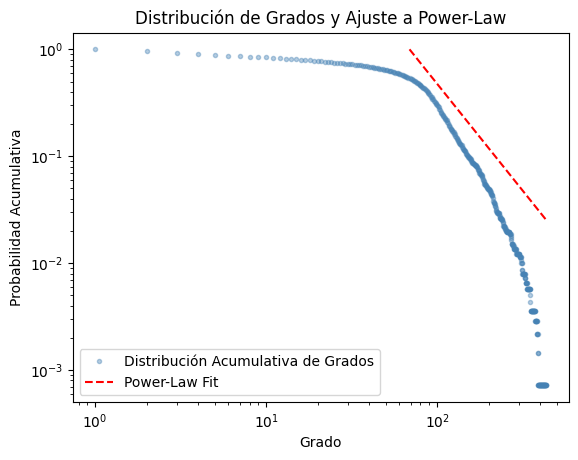

In [68]:
# Calculamos la distribución de grados y su distribución acumulativa
degree_dist = np.bincount(degree_values)[1:]  # Omitimos el grado 0
degree_dist_cumulative = np.cumsum(degree_dist[::-1])[::-1]  # Distribución acumulativa

# Normalizamos la distribución acumulativa
degree_dist_cumulative = degree_dist_cumulative / sum(degree_dist)

# Creamos un rango para los grados
degrees_range = np.arange(1, len(degree_dist_cumulative) + 1)

# Visualizamos la distribución acumulativa de grados
plt.figure()
plt.loglog(degrees_range,
           degree_dist_cumulative, 
           marker='o',
           linestyle='none',
           markersize=3,
           alpha=0.4,
           label='Distribución Acumulativa de Grados', 
           color='steelblue')

# Plot the Power-Law fit, if available
if 'fit' in locals():
    xmin = fit.power_law.xmin
    x_vals = np.arange(xmin, max(degrees_range))
    y_vals = (x_vals / xmin) ** (-fit.power_law.alpha + 1)
    plt.loglog(x_vals, y_vals, color='red', linestyle='--', label='Power-Law Fit')

# Add labels and title
plt.xlabel("Grado")
plt.ylabel("Probabilidad Acumulativa")
plt.title("Distribución de Grados y Ajuste a Power-Law")


plt.legend()
plt.show()

Como se esperaba el ajuste de Power-law no aplica para esta distribución.

### 3.3

In [ ]:

# Clustering coefficient (global transitivity)
clustering = nx.transitivity(gc)
print(f"Clustering: {clustering}")

# Entropy of nodes
entropia = -np.sum(distribucion_grados * np.log(distribucion_grados + 1e-10))
print(f"Entropía de los Nodos: {entropia}")

# Centrality measures
centralidad_cercania = nx.closeness_centrality(gc, distance='weight' if nx.is_weighted(gc) else None)
centralidad_intermediacion = nx.betweenness_centrality(gc, normalized=True, weight='weight' if nx.is_weighted(gc) else None)

# Correlation between closeness and betweenness centrality
correlacion_centralidades = np.corrcoef(list(centralidad_cercania.values()), list(centralidad_intermediacion.values()))[0, 1]
print(f"Correlación entre las dos centralidades: {correlacion_centralidades}")

# Correlation between degree and betweenness
correlacion_grado_centralidad = np.corrcoef(list(degrees.values()), list(centralidad_intermediacion.values()))[0, 1]
print(f"Correlación entre Grado y betweenness: {correlacion_grado_centralidad}")


## 4. Análisis de comunidades de la componente conexa mayor (1.5 puntos)
En este apartado, se pide aplicar dos algoritmos de detección de comunidades sobre la componente conexa mayor, compararlos y seleccionar cuál es, en tu opinión, el que da una mejor respuesta. Razona tu selección.

In [ ]:
# Inserta aqui tu codigo

## 5. Visualización del grafo por comunidades de la componente conexa mayor (1.5 puntos)
En este apartado, se pide visualizar el grafo coloreando cada nodo en función de la comunidad a la que pertenezca, según tu elección del apartado anterior.


In [ ]:
# Inserta aqui tu codigo

## 6. Difundiendo un rumor (o un virus) en la componente conexa mayor (4 puntos)
Este apartado es el que más peso en la práctica tiene. Vamos a implementar un modelo epidemiológico sobre el grafo que, típicamente, se utiliza para simular escenarios de difusión de enfermedades pero también en contextos como la distribución de rumores e información. Vamos a implementar un modelo SIR que se caracteriza por tener los siguientes parámetros:

* Número de nodos iniciales infectados en el momento t=0 (N).
* Beta: probabilidad de contagio de un nodo infectado (I) a un nodo susceptible de serlo (S)
* Gamma: probabilidad de que un nodo infectado (I) se recupere en momenteo actual (R). Los nodos en estado (R) no son susceptibles y permanecen en este estado infinitamente. Un nodo no puede infectarse y recuperarse en el mismo paso.

Se pide desarrollar una función que tenga como parámetros los tres valores anteriores y un cuarto que sea un grafo que, en nuestro caso, será la componente conexa mayor del grafo original de esta práctica. Dicha función simulará el proceso SIR:

* En t=0, se seleccionan N nodos al azar, que pasarán a estado infectado.
* En t=1, se podrán contagiar con probabilidad Beta nodos que tienen un vecino infectado; OJO: si un nodo en estado S tiene varios vecinos en estado I tiene más probabilidad de infectarse ya que cada vecino tendrá un intento de infectarle.
* Se repite el paso anterior sucesivamente, hasta que no vemos infectados nuevos durante, al menos, 3 iteraciones.

Se pide ejecutar una simulación para tres o cuatro valores del parámetro beta (N y gamma pueden ser fijos en estas simulaciones) de este proceso de manera que se pueda visualizar:

* La curva de nuevos infectados en escala logarítmica para cada caso.
* Las curvas acumuladas para ver el porcentaje total de infectados en cada escenario.
* El grafo que surge de la cascada de contagios: es decir, dos nodos están enlazados ahora si uno ha contagiado al otro. Como es lógico, tanto los nodos como los enlaces de este nuevo grafo son un subconjunto del grafo original.

In [ ]:
# Inserta aqui tu codigo


## 

## 